<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab%2011/%5BLab_11%5D_Dirty_Data_Forensics_and_Structural_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install category_encoders

import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce

# Step 1: Ingestion from external source
url = 'https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/main/Data/messy_hr_economics.csv'
df = pd.read_csv(url)

<Axes: >

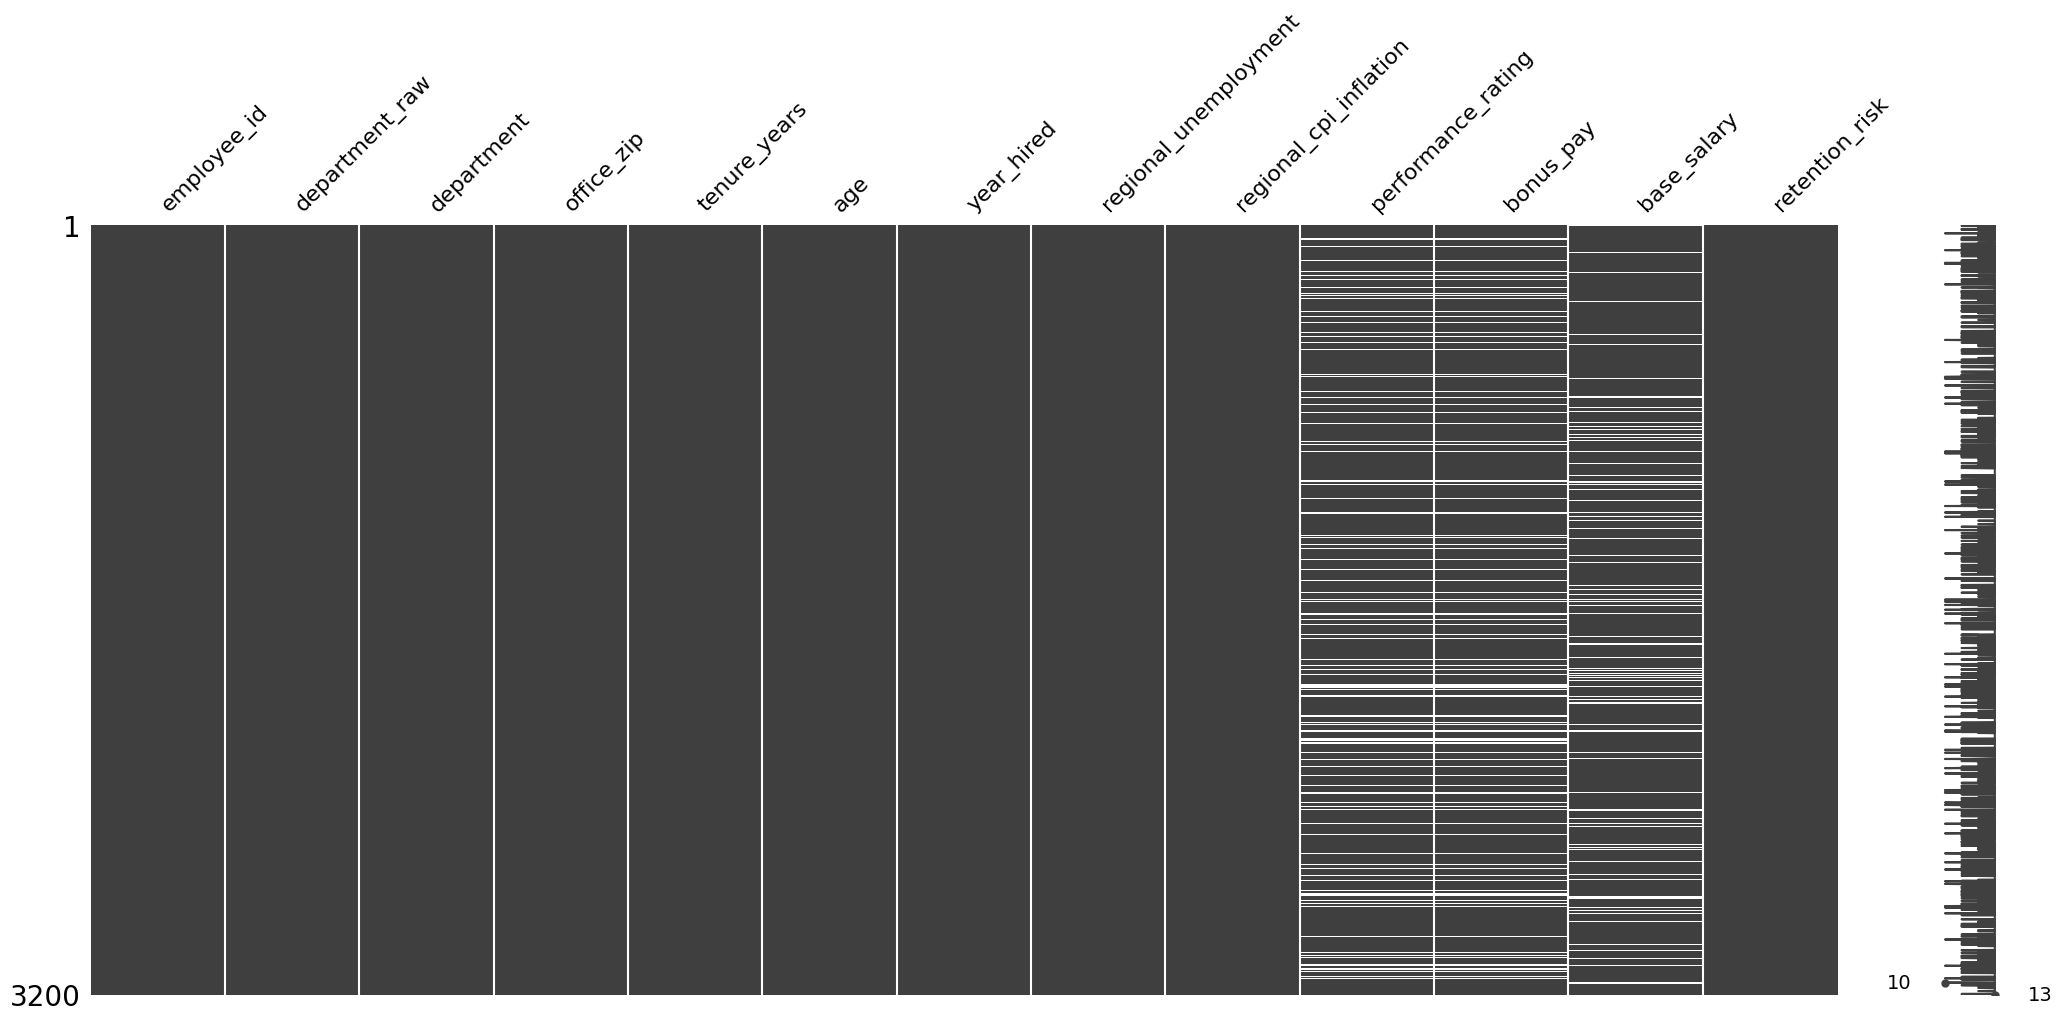

In [8]:
# Step 2: Visual Forensics
msno.matrix(df)

# Instructor Note: Students should visually observe that missing 'bonus_pay'
# perfectly aligns with missing 'performance_rating'.
# This structural alignment indicates MAR (Missing at Random).

In [9]:
# Step 3: Grouped Conditional Imputation
# Imputing the median salary based on department to preserve variance structures
df['base_salary'] = df.groupby('department')['base_salary'].transform(lambda x: x.fillna(x.median()))

In [10]:
# Step 4: The Dummy Variable Trap (Intentional Failure)
dummies_trap = pd.get_dummies(df['department'],prefix='dept').astype(int)
X_trap = pd.concat([df[['tenure_years']], dummies_trap], axis=1)

# Adding the constant intercept creates perfect multicollinearity
X_trap = sm.add_constant(X_trap)
y = df['base_salary']

# This will trigger a severe multicollinearity warning or a LinAlgError
model_trap = sm.OLS(y, X_trap).fit()
print(model_trap.summary())

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:10:02   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             5.765e+04    244.020  

In [11]:
# Step 5: Escaping the Trap (k-1 methodology)
# drop_first=True establishes the reference category
dummies_safe = pd.get_dummies(df['department'],prefix='dept',drop_first=True).astype(int)
X_safe = pd.concat([df[['tenure_years']], dummies_safe], axis=1)
X_safe = sm.add_constant(X_safe)
model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

# Step 5b: Target Encoding High Cardinality
# Condensing 800 ZIP codes into a single continuous vector representing average salary
encoder = ce.TargetEncoder(cols=['office_zip'])
df['zip_encoded'] = encoder.fit_transform(df['office_zip'], df['base_salary'])

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     3090.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        00:10:41   Log-Likelihood:                -34010.
No. Observations:                3200   AIC:                         6.803e+04
Df Residuals:                    3196   BIC:                         6.805e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           9.527e+04    372.412    255.

🤖 AI-Assisted Expansion

In [14]:
!pip install streamlit

"""
Interactive Visual Forensics Dashboard
Econometrics Lab Expansion — P.R.I.M.E. Framework
"""

import streamlit as st
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

# ─────────────────────────────────────────────────────────────────────────────
# PAGE CONFIG
# ─────────────────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Visual Forensics Dashboard",
    page_icon="🔬",
    layout="wide",
)

st.title("🔬 Visual Forensics Dashboard")
st.markdown(
    "Upload a CSV, inspect its missingness pattern, then apply **conditional median imputation** with one click."
)

# ─────────────────────────────────────────────────────────────────────────────
# SESSION STATE — holds the dataset across reruns
# ─────────────────────────────────────────────────────────────────────────────
# st.session_state is a dictionary-like object that Streamlit preserves
# between every script rerun (which happens whenever the user interacts with
# any widget).  Without it, variables declared inside this script would reset
# to None each time a button is clicked.
#
# We initialise two keys here so that later code can safely read them even
# before the user has uploaded anything:
#   • "df_raw"      — the original, unmodified DataFrame
#   • "df_imputed"  — the DataFrame after imputation has been applied

if "df_raw" not in st.session_state:
    st.session_state["df_raw"] = None          # no data yet

if "df_imputed" not in st.session_state:
    st.session_state["df_imputed"] = None      # imputation not yet run


# ─────────────────────────────────────────────────────────────────────────────
# @st.cache_data — caching the CSV loader
# ─────────────────────────────────────────────────────────────────────────────
# @st.cache_data tells Streamlit: "if this function is called again with the
# *same* arguments, return the previously computed result instead of running
# the function body again."
#
# Here the argument is `file_bytes` (the raw bytes of the uploaded file).
# Streamlit hashes those bytes; if the user uploads the same file twice the
# DataFrame is served from cache instantly — no redundant pd.read_csv call.
# The decorator is ideal for pure, deterministic data-loading functions.

@st.cache_data
def load_csv(file_bytes: bytes) -> pd.DataFrame:
    """Parse raw CSV bytes into a DataFrame (result is cached by file content)."""
    import io
    return pd.read_csv(io.BytesIO(file_bytes))


# ─────────────────────────────────────────────────────────────────────────────
# SIDEBAR — upload + column selector
# ─────────────────────────────────────────────────────────────────────────────
with st.sidebar:
    st.header("⚙️ Controls")

    uploaded_file = st.file_uploader(
        "Upload a CSV file",
        type=["csv"],
        help="Any CSV with at least one numeric column works.",
    )

    if uploaded_file is not None:
        # Read bytes once; cache_data will memoize the parse step
        file_bytes = uploaded_file.getvalue()
        df_loaded = load_csv(file_bytes)

        # Store the freshly loaded DataFrame in session state so the rest of
        # the app (and future reruns) can access it without re-reading the file
        st.session_state["df_raw"] = df_loaded
        st.session_state["df_imputed"] = None   # reset any previous imputation

    # Only show column controls once data is loaded
    if st.session_state["df_raw"] is not None:
        df = st.session_state["df_raw"]
        numeric_cols = df.select_dtypes(include="number").columns.tolist()

        st.markdown("---")
        st.subheader("Imputation Settings")

        target_col = st.selectbox(
            "Column to impute",
            options=numeric_cols,
            help="The numeric column whose missing values will be filled.",
        )

        cat_cols = [c for c in df.columns if df[c].dtype == object]
        group_col = st.selectbox(
            "Group-by column (conditional)",
            options=["— none —"] + cat_cols,
            help="Impute the median *within* each group of this column.",
        )

        run_btn = st.button("▶ Run Imputation", type="primary", use_container_width=True)
    else:
        run_btn = False
        target_col = None
        group_col = None


# ─────────────────────────────────────────────────────────────────────────────
# HELPER — render a missingno matrix in a Matplotlib figure
# ─────────────────────────────────────────────────────────────────────────────
def plot_msno_matrix(dataframe: pd.DataFrame, title: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(12, 5))
    msno.matrix(dataframe, ax=ax, sparkline=False, fontsize=10)
    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    return fig


# ─────────────────────────────────────────────────────────────────────────────
# MAIN PANEL
# ─────────────────────────────────────────────────────────────────────────────
if st.session_state["df_raw"] is None:
    # ── Landing state: no file uploaded yet ──────────────────────────────────
    st.info("👈  Upload a CSV in the sidebar to get started.")

    # Show a preview with the lab's built-in dataset
    st.markdown("### 📋 No file yet? Try the lab dataset")
    demo_url = (
        "https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning"
        "/main/Data/messy_hr_economics.csv"
    )
    if st.button("Load demo HR Economics dataset"):
        try:
            df_demo = pd.read_csv(demo_url)
            st.session_state["df_raw"] = df_demo
            st.rerun()
        except Exception as e:
            st.error(f"Could not fetch demo data: {e}")

else:
    # ── Data is loaded — show the dashboard ──────────────────────────────────
    df_raw: pd.DataFrame = st.session_state["df_raw"]

    # ── Section 1: Data Preview ───────────────────────────────────────────────
    with st.expander("📄 Raw Data Preview", expanded=False):
        st.dataframe(df_raw.head(50), use_container_width=True)
        c1, c2, c3 = st.columns(3)
        c1.metric("Rows", f"{df_raw.shape[0]:,}")
        c2.metric("Columns", df_raw.shape[1])
        c3.metric("Missing cells", f"{df_raw.isna().sum().sum():,}")

    # ── Section 2: Missingness Matrix (Before) ────────────────────────────────
    st.subheader("🗺️ Missingness Matrix — Before Imputation")
    st.markdown(
        "Each **white stripe** marks a missing value. "
        "Aligned gaps across columns reveal structural (MAR) patterns."
    )
    fig_before = plot_msno_matrix(df_raw, "Missingness Pattern — Raw Data")
    st.pyplot(fig_before, use_container_width=True)
    plt.close(fig_before)

    # ── Section 3: Missing-value summary table ────────────────────────────────
    st.subheader("📊 Column-level Missing Summary")
    miss_summary = (
        df_raw.isna()
        .sum()
        .rename("missing_count")
        .to_frame()
        .assign(missing_pct=lambda d: (d["missing_count"] / len(df_raw) * 100).round(2))
        .query("missing_count > 0")
        .sort_values("missing_pct", ascending=False)
        .reset_index()
        .rename(columns={"index": "column"})
    )

    if miss_summary.empty:
        st.success("✅ No missing values detected in this dataset.")
    else:
        st.dataframe(miss_summary, use_container_width=True)

    # ── Section 4: Imputation ─────────────────────────────────────────────────
    st.subheader("🛠️ Conditional Median Imputation")

    if run_btn and target_col:
        df_imp = df_raw.copy()

        if group_col and group_col != "— none —":
            # Conditional: fill NaN with the median *within each group*
            df_imp[target_col] = df_imp.groupby(group_col)[target_col].transform(
                lambda s: s.fillna(s.median())
            )
            label = f"Median of `{target_col}` within each `{group_col}` group"
        else:
            # Unconditional: global median
            global_median = df_imp[target_col].median()
            df_imp[target_col] = df_imp[target_col].fillna(global_median)
            label = f"Global median of `{target_col}` ({global_median:.2f})"

        # Persist the imputed DataFrame in session state so it survives reruns
        st.session_state["df_imputed"] = df_imp

        st.success(f"✅ Imputed missing values using: **{label}**")

    # Show after-imputation matrix if imputation has been run
    if st.session_state["df_imputed"] is not None:
        df_imp: pd.DataFrame = st.session_state["df_imputed"]

        st.subheader("🗺️ Missingness Matrix — After Imputation")
        fig_after = plot_msno_matrix(df_imp, "Missingness Pattern — After Imputation")
        st.pyplot(fig_after, use_container_width=True)
        plt.close(fig_after)

        remaining = df_imp.isna().sum().sum()
        if remaining == 0:
            st.success("🎉 All missing values resolved.")
        else:
            st.warning(
                f"⚠️ {remaining:,} missing values remain "
                "(likely in non-numeric or unselected columns)."
            )

        # Download button for the imputed CSV
        csv_bytes = df_imp.to_csv(index=False).encode()
        st.download_button(
            label="⬇️ Download imputed CSV",
            data=csv_bytes,
            file_name="imputed_data.csv",
            mime="text/csv",
            use_container_width=True,
        )
    else:
        st.info("Configure the imputation settings in the sidebar, then click **▶ Run Imputation**.")

# ─────────────────────────────────────────────────────────────────────────────
# FOOTER
# ─────────────────────────────────────────────────────────────────────────────
st.markdown("---")
st.caption("ECON 3916 | Visual Forensics Dashboard | Built with Streamlit + missingno")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 45.1 MB/s eta 0:00:00


2026-03-12 00:16:25.640 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 00:16:25.643 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 00:16:25.976 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-12 00:16:25.978 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 00:16:25.979 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 00:16:25.981 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-12 00:16:25.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

DeltaGenerator()